In [1]:
import pandas as pd

# Load the datasets
df_cpf = pd.read_csv('yearly-amount-of-monthly-payout-under-cpf-life-scheme.csv')
df_rss = pd.read_csv('yearly-amount-of-monthly-payout-under-retirement-sum-scheme.csv')
df_other = pd.read_csv('yearly-net-amount-of-other-retirement-withdrawals.csv')

# Inspect the data
print("CPF LIFE:")
print(df_cpf.head())
print(df_cpf.info())

print("\nRSS:")
print(df_rss.head())
print(df_rss.info())

print("\nOther Withdrawals:")
print(df_other.head())
print(df_other.info())

CPF LIFE:
     yr  mthly_payout_amt
0  2010          43700000
1  2011          85600000
2  2012         100500000
3  2013         120400000
4  2014         159300000
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   yr                11 non-null     int64
 1   mthly_payout_amt  11 non-null     int64
dtypes: int64(2)
memory usage: 308.0 bytes
None

RSS:
     yr  mthly_payout_amt
0  2006         240300000
1  2007         218900000
2  2008         229700000
3  2009         265700000
4  2010         298200000
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   yr                15 non-null     int64
 1   mthly_payout_amt  15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes
None

Other Withdrawals:
     yr  net_w

      yr  rss_payout   other_wdl     cpf_life
0   2006   240300000  2485400000          NaN
1   2007   218900000  2523600000          NaN
2   2008   229700000  2138100000          NaN
3   2009   265700000  1805900000          NaN
4   2010   298200000  1780900000   43700000.0
5   2011   344000000  1970200000   85600000.0
6   2012   370200000  2064300000  100500000.0
7   2013   398400000  2803000000  120400000.0
8   2014   457100000  2932900000  159300000.0
9   2015   501500000  3707000000  183500000.0
10  2016   566800000  3332600000  213000000.0
11  2017   662000000  4064200000  273000000.0
12  2018   781900000  5534500000  322600000.0
13  2019   953200000  5208800000  377500000.0
14  2020  1375000000  4599300000  465800000.0


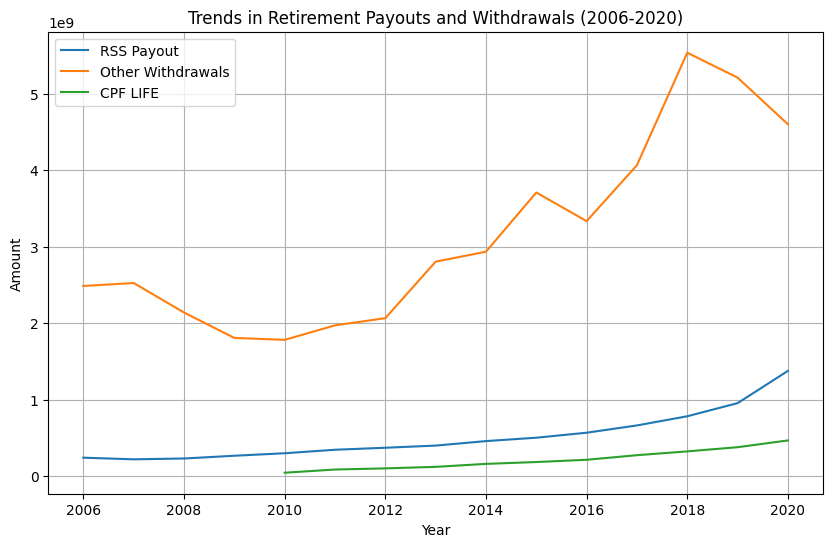

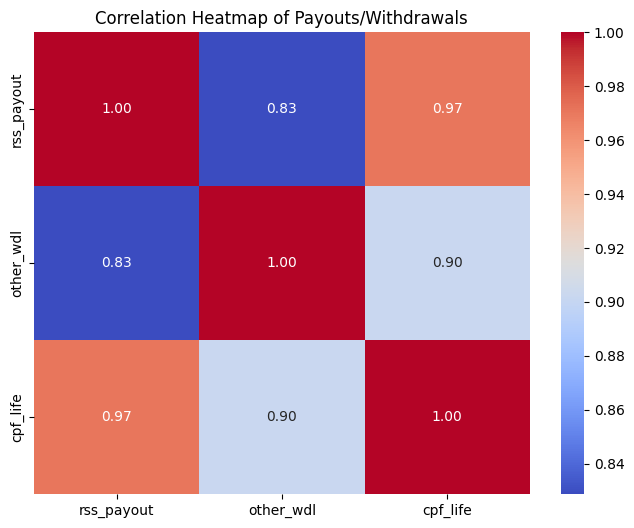

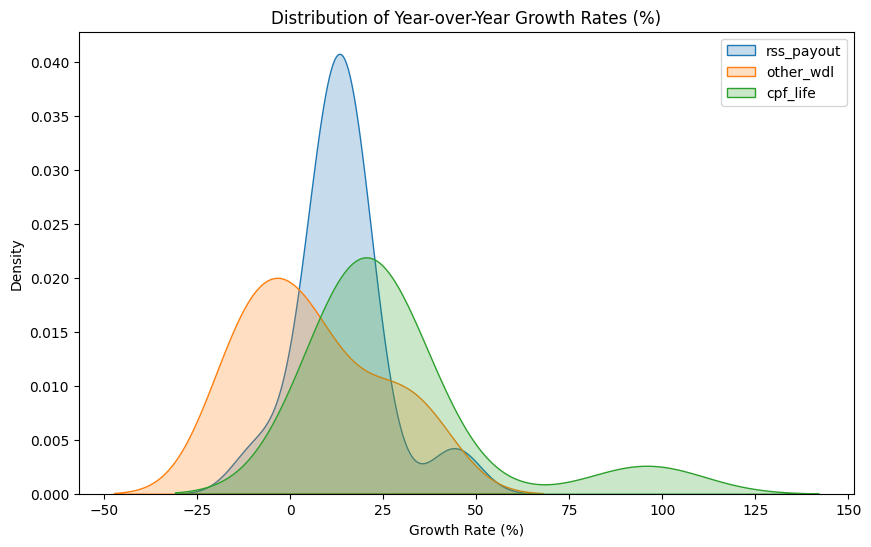

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Merge the dataframes
df_merged = df_rss.rename(columns={'mthly_payout_amt': 'rss_payout'})
df_merged = pd.merge(df_merged, df_other.rename(columns={'net_wdl_amt': 'other_wdl'}), on='yr', how='outer')
df_merged = pd.merge(df_merged, df_cpf.rename(columns={'mthly_payout_amt': 'cpf_life'}), on='yr', how='outer')

# Sort by year
df_merged = df_merged.sort_values('yr')

# Display merged data
print(df_merged)

# 1. Price Trend (Payout/Withdrawal Trends)
plt.figure(figsize=(10, 6))
plt.plot(df_merged['yr'], df_merged['rss_payout'], label='RSS Payout')
plt.plot(df_merged['yr'], df_merged['other_wdl'], label='Other Withdrawals')
plt.plot(df_merged['yr'], df_merged['cpf_life'], label='CPF LIFE')
plt.title('Trends in Retirement Payouts and Withdrawals (2006-2020)')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.savefig('trends.png')

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df_merged[['rss_payout', 'other_wdl', 'cpf_life']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Payouts/Withdrawals')
plt.savefig('correlation.png')

# 3. Return Distribution (YoY Growth Rate)
# Calculate YoY percentage change for each category
df_returns = df_merged.copy()
df_returns[['rss_payout', 'other_wdl', 'cpf_life']] = df_returns[['rss_payout', 'other_wdl', 'cpf_life']].pct_change() * 100

plt.figure(figsize=(10, 6))
for col in ['rss_payout', 'other_wdl', 'cpf_life']:
    sns.kdeplot(df_returns[col].dropna(), label=col, fill=True)
plt.title('Distribution of Year-over-Year Growth Rates (%)')
plt.xlabel('Growth Rate (%)')
plt.ylabel('Density')
plt.legend()
plt.savefig('returns_distribution.png')

# Save merged data for user reference
df_merged.to_csv('merged_retirement_data.csv', index=False)